In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [5]:
discovery_path = "/Users/khushdomadiya/Documents/Healthcare/archive/Clinical Data_Discovery_Cohort.csv"
df_discovery = pd.read_csv(discovery_path)

df_discovery.head()


,PatientID,Specimen date,Dead or Alive,Date of Death,Date of Last Follow Up,sex,race,Stage,Event,Time
0,1,3/17/2003,Dead,2/24/2010,2/24/2010,F,B,pT2N2MX,1,2536
1,2,6/17/2003,Dead,11/12/2004,11/12/2004,M,W,T2N2MX,1,514
2,3,9/9/2003,Dead,8/1/2009,8/1/2009,F,B,T2N1MX,1,2153
3,4,10/14/2003,Dead,12/29/2006,12/29/2006,M,W,pT2NOMX,1,1172
4,5,12/1/2003,Dead,1/31/2004,1/31/2004,F,W,T2NOMX,1,61


In [21]:
validation_path = "/Users/khushdomadiya/Documents/Healthcare/archive/Clinical_Data_Validation_Cohort.xlsx"
df_validation = pd.read_excel(validation_path)  # default reads first sheet

df_validation.head()
df_validation.tail()

,Patient ID,Survival time (days),"Event (death: 1, alive: 0)",Tumor size (cm),Grade,Stage (TNM 8th edition),Age,Sex,Cigarette,Pack per year,Type.Adjuvant,batch,EGFR,KRAS
90,P137984,1919,0,1.8,1,IA2,67,Male,Former,40.0,NaN,3,Negative,G12D
91,P138002,1911,0,2.3,3,IA3,71,Male,Current,45.0,NaN,3,Negative,Negative
92,P138007,1935,0,2.8,3,IIB,68,Female,Former,60.0,Chemo,3,Negative,G12V
93,P138013,1760,0,2.4,2,IB,50,Female,Former,16.0,NaN,3,Negative,G12A
94,P138014,1922,0,2.1,2,Recurrence,69,Female,Never,0.0,NaN,3,Exon 19,NaN


In [7]:
df_discovery.shape, df_validation.shape


((30, 10), (95, 14))

In [8]:
df_discovery.info()
df_validation.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   PatientID               30 non-null     int64 
 1   Specimen date           30 non-null     object
 2   Dead or Alive           30 non-null     object
 3   Date of Death           30 non-null     object
 4   Date of Last Follow Up  30 non-null     object
 5   sex                     30 non-null     object
 6   race                    30 non-null     object
 7   Stage                   30 non-null     object
 8   Event                   30 non-null     int64 
 9   Time                    30 non-null     int64 
dtypes: int64(3), object(7)
memory usage: 2.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   P

In [9]:
df_discovery.isna().sum()
df_validation.isna().sum()


Patient ID                     0
Survival time (days)           0
Event (death: 1, alive: 0)     0
Tumor size (cm)                0
Grade                          0
Stage (TNM 8th edition)        0
Age                            0
Sex                            0
Cigarette                      0
Pack per year                  0
Type.Adjuvant                 73
batch                          0
EGFR                           9
KRAS                          30
dtype: int64

In [10]:
df_validation['Stage (TNM 8th edition)'].value_counts()


Stage (TNM 8th edition)
IB            21
IA2           20
IA3           20
IIIA          13
IIB           12
Recurrence     3
IIIB           3
IIA            2
IVA            1
Name: count, dtype: int64

In [13]:
df_validation.groupby('Stage (TNM 8th edition)')['Tumor size (cm)'].describe()


,count,mean,std,min,25%,50%,75%,max
Stage (TNM 8th edition),,,,,,,,
IA2,20.0,1.605000,0.315353,1.1,1.375,1.70,1.825,2.0
IA3,20.0,2.510000,0.284513,2.1,2.300,2.45,2.650,3.0
IB,21.0,2.833333,0.847545,1.6,2.000,2.80,3.500,4.0
IIA,2.0,4.600000,0.565685,4.2,4.400,4.60,4.800,5.0
IIB,12.0,4.150000,1.822835,2.0,2.700,3.50,5.450,7.0
IIIA,13.0,3.876923,1.595908,1.7,2.500,4.00,5.000,6.3
IIIB,3.0,3.733333,2.411086,1.2,2.600,4.00,5.000,6.0
IVA,1.0,2.400000,NaN,2.4,2.400,2.40,2.400,2.4
Recurrence,3.0,2.133333,0.650641,1.5,1.800,2.10,2.450,2.8


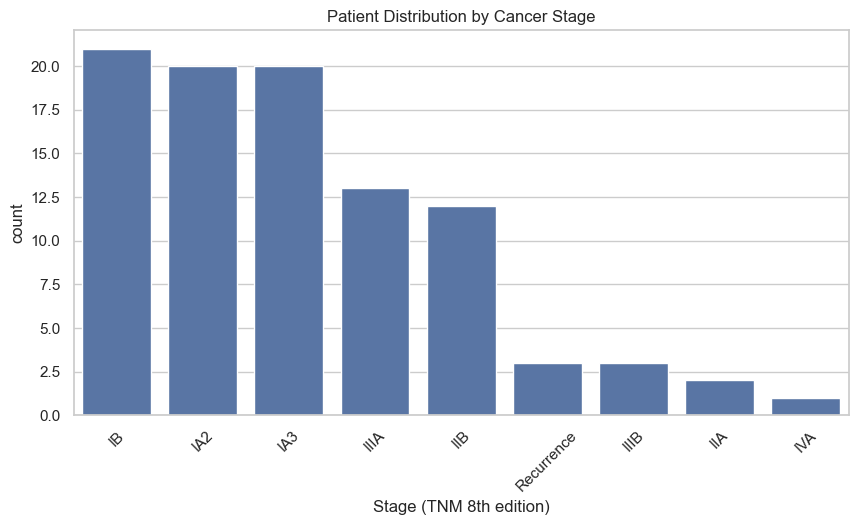

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_validation,
    x='Stage (TNM 8th edition)',
    order=df_validation['Stage (TNM 8th edition)'].value_counts().index
)
plt.xticks(rotation=45)
plt.title('Patient Distribution by Cancer Stage')
plt.show()


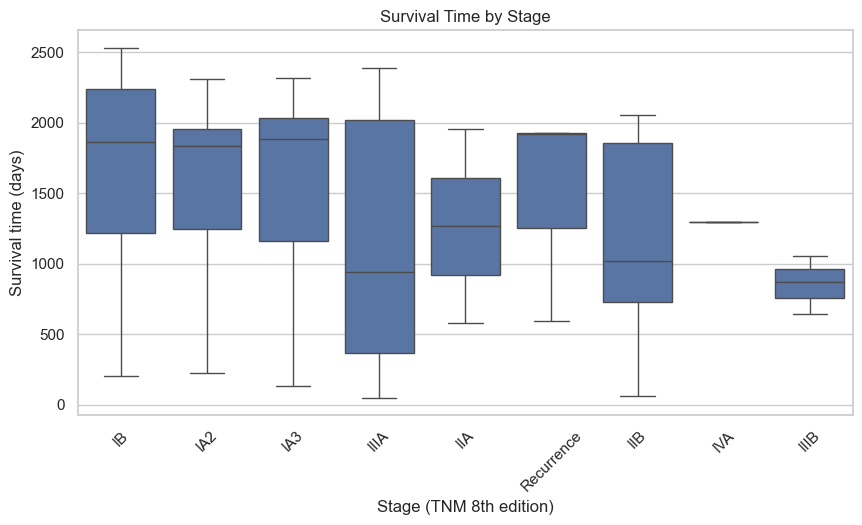

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_validation,
    x='Stage (TNM 8th edition)',
    y='Survival time (days)'
)
plt.xticks(rotation=45)
plt.title('Survival Time by Stage')
plt.show()


In [24]:
df_validation.groupby('Stage (TNM 8th edition)')['Event (death: 1, alive: 0)'].mean().sort_values()


Stage (TNM 8th edition)
IA3           0.200000
IB            0.285714
IA2           0.400000
IIB           0.416667
IIA           0.500000
Recurrence    0.666667
IIIA          0.692308
IIIB          1.000000
IVA           1.000000
Name: Event (death: 1, alive: 0), dtype: float64

In [25]:
pd.crosstab(
    df_validation['Stage (TNM 8th edition)'],
    df_validation['Type.Adjuvant'],
    normalize='index'
).round(2)


Type.Adjuvant,Chemo,Chemorad,XRT
Stage (TNM 8th edition),,,
IA3,0.75,0.25,0.00
IB,1.00,0.00,0.00
IIA,1.00,0.00,0.00
IIB,1.00,0.00,0.00
IIIA,0.50,0.33,0.17
IIIB,0.50,0.50,0.00
IVA,1.00,0.00,0.00


In [29]:
df_validation['Type.Adjuvant'].value_counts(dropna=False)


Type.Adjuvant
NaN         73
Chemo       17
Chemorad     4
XRT          1
Name: count, dtype: int64

In [30]:
df_validation['Type.Adjuvant'] = (
    df_validation['Type.Adjuvant']
    .fillna('None')
    .replace(['NA', 'na', 'N/A'], 'None')
    .str.strip()
)


In [31]:
pd.crosstab(
    df_validation['Stage (TNM 8th edition)'],
    df_validation['Type.Adjuvant'],
    normalize='index'
).round(2)


Type.Adjuvant,Chemo,Chemorad,None,XRT
Stage (TNM 8th edition),,,,
IA2,0.00,0.00,1.00,0.00
IA3,0.15,0.05,0.80,0.00
IB,0.10,0.00,0.90,0.00
IIA,0.50,0.00,0.50,0.00
IIB,0.50,0.00,0.50,0.00
IIIA,0.23,0.15,0.54,0.08
IIIB,0.33,0.33,0.33,0.00
IVA,1.00,0.00,0.00,0.00
Recurrence,0.00,0.00,1.00,0.00


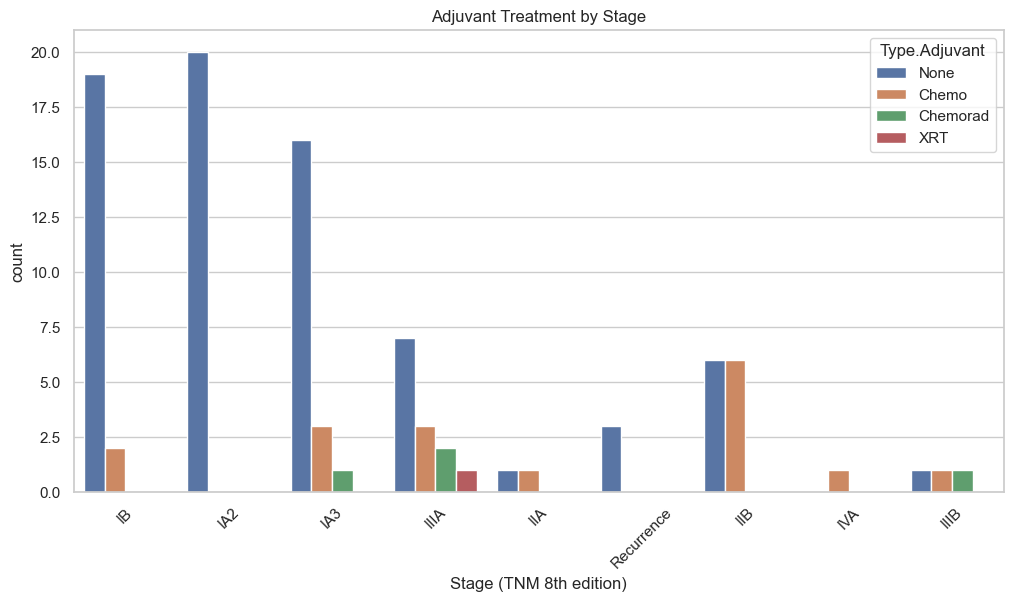

In [37]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_validation,
    x='Stage (TNM 8th edition)',
    hue='Type.Adjuvant'
)
plt.xticks(rotation=45)
plt.title('Adjuvant Treatment by Stage')
plt.show()


In [38]:
df_validation[
    df_validation['Stage (TNM 8th edition)'].isin(['Recurrence', 'IIIA'])
].groupby(['Stage (TNM 8th edition)', 'Type.Adjuvant']).size().unstack().fillna(0)


Type.Adjuvant,Chemo,Chemorad,None,XRT
Stage (TNM 8th edition),,,,
IIIA,3.0,2.0,7.0,1.0
Recurrence,0.0,0.0,3.0,0.0


In [39]:
df_validation.groupby('Stage (TNM 8th edition)')['Survival time (days)'].describe()


,count,mean,std,min,25%,50%,75%,max
Stage (TNM 8th edition),,,,,,,,
IA2,20.0,1623.800000,582.703102,228.0,1245.50,1837.5,1958.00,2314.0
IA3,20.0,1554.650000,675.241888,135.0,1163.50,1887.5,2037.75,2318.0
IB,21.0,1731.285714,601.435628,208.0,1217.00,1865.0,2238.00,2532.0
IIA,2.0,1267.500000,973.686038,579.0,923.25,1267.5,1611.75,1956.0
IIB,12.0,1160.416667,694.398164,66.0,727.50,1023.5,1859.25,2059.0
IIIA,13.0,1160.923077,823.223791,50.0,366.00,942.0,2022.00,2387.0
IIIB,3.0,858.333333,203.951792,647.0,760.50,874.0,964.00,1054.0
IVA,1.0,1300.000000,NaN,1300.0,1300.00,1300.0,1300.00,1300.0
Recurrence,3.0,1480.333333,769.323296,592.0,1257.00,1922.0,1924.50,1927.0


In [40]:
pd.crosstab(
    df_validation['Cigarette'],
    df_validation['EGFR'],
    normalize='index'
).round(2)


EGFR,Exon 19,Exon 19 (15bp delete),Exon 19 (24bp delete),Exon 19 (9bp delete),Exon 21,Exon 21 (L858R),Negative
Cigarette,,,,,,,
Current,0.00,0.00,0.00,0.09,0.00,0.00,0.91
Former,0.11,0.02,0.00,0.02,0.00,0.02,0.84
Never,0.11,0.05,0.05,0.00,0.16,0.16,0.47


In [41]:
pd.crosstab(
    df_validation['Cigarette'],
    df_validation['KRAS'],
    normalize='index'
).round(2)


KRAS,G12A,G12C,G12D,G12F,G12R,G12V,G13C,G13D,G13F,G13R,Negative
Cigarette,,,,,,,,,,,
Current,0.00,0.30,0.10,0.10,0.00,0.20,0.00,0.00,0.00,0.00,0.30
Former,0.07,0.13,0.11,0.02,0.02,0.11,0.02,0.02,0.02,0.02,0.46
Never,0.00,0.00,0.00,0.00,0.00,0.11,0.00,0.00,0.00,0.00,0.89


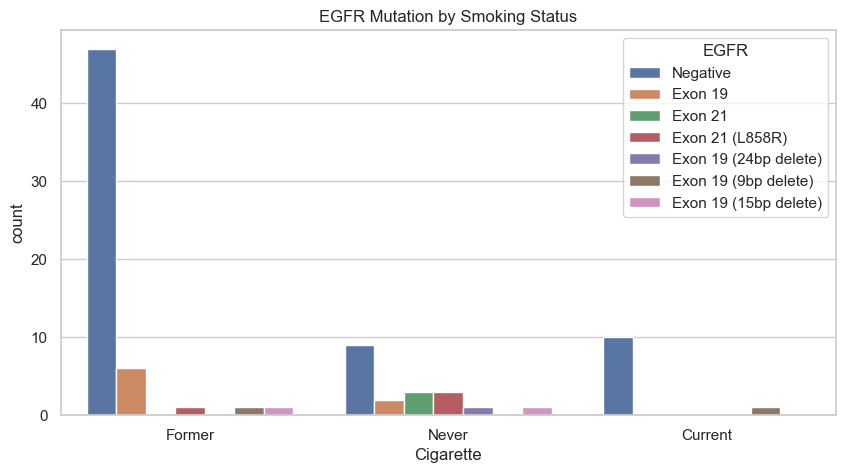

In [42]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_validation,
    x='Cigarette',
    hue='EGFR'
)
plt.title('EGFR Mutation by Smoking Status')
plt.show()


In [43]:
df_validation.groupby('EGFR')['Survival time (days)'].describe()

,count,mean,std,min,25%,50%,75%,max
EGFR,,,,,,,,
Exon 19,8.0,1985.125000,326.017720,1300.0,1907.75,1990.5,2249.50,2295.0
Exon 19 (15bp delete),2.0,728.500000,460.326515,403.0,565.75,728.5,891.25,1054.0
Exon 19 (24bp delete),1.0,1986.000000,NaN,1986.0,1986.00,1986.0,1986.00,1986.0
Exon 19 (9bp delete),2.0,1464.000000,162.634560,1349.0,1406.50,1464.0,1521.50,1579.0
Exon 21,3.0,1509.333333,712.414439,837.0,1136.00,1435.0,1845.50,2256.0
Exon 21 (L858R),4.0,750.500000,825.110296,66.0,187.50,523.5,1086.50,1889.0
Negative,66.0,1497.606061,673.563266,50.0,927.75,1822.0,2009.75,2532.0


In [44]:
df_validation.groupby('KRAS')['Survival time (days)'].describe()

,count,mean,std,min,25%,50%,75%,max
KRAS,,,,,,,,
G12A,3.0,1542.333333,442.644703,1033.0,1396.50,1760.0,1797.00,1834.0
G12C,9.0,1240.888889,787.673861,299.0,453.00,1161.0,2022.00,2193.0
G12D,6.0,1101.000000,546.351169,354.0,806.75,1065.0,1378.00,1919.0
G12F,2.0,1505.500000,729.027091,990.0,1247.75,1505.5,1763.25,2021.0
G12R,1.0,1945.000000,NaN,1945.0,1945.00,1945.0,1945.00,1945.0
G12V,8.0,1576.375000,548.761186,895.0,1034.75,1740.5,1992.25,2237.0
G13C,1.0,681.000000,NaN,681.0,681.00,681.0,681.00,681.0
G13D,1.0,1881.000000,NaN,1881.0,1881.00,1881.0,1881.00,1881.0
G13F,1.0,1860.000000,NaN,1860.0,1860.00,1860.0,1860.00,1860.0


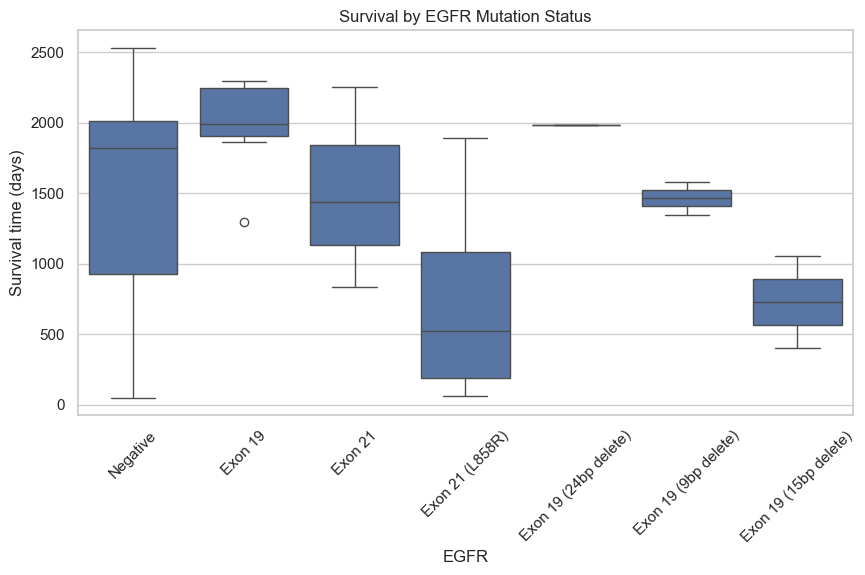

In [48]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_validation,
    x='EGFR',
    y='Survival time (days)'
)
plt.xticks(rotation=45)
plt.title('Survival by EGFR Mutation Status')
plt.show()


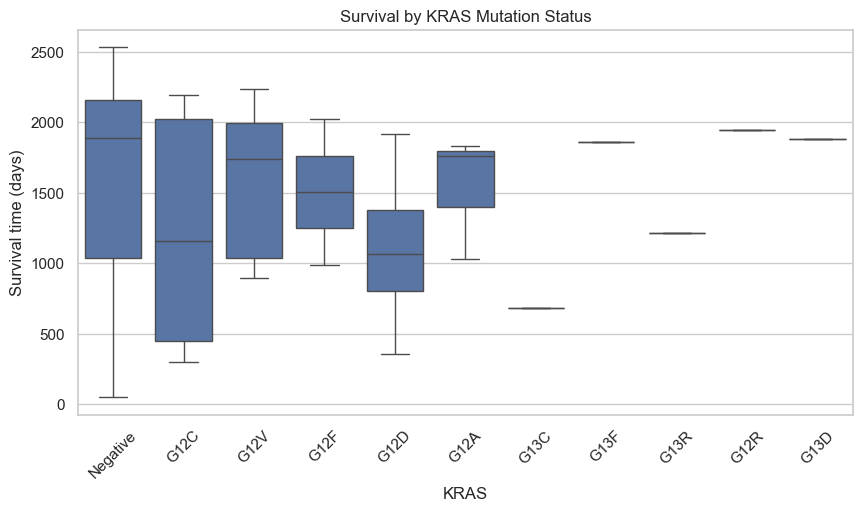

In [56]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_validation,
    x='KRAS',
    y='Survival time (days)'
)
plt.xticks(rotation=45)
plt.title('Survival by KRAS Mutation Status')
plt.show()


In [57]:
# Risk Stratification

In [58]:
df_validation.groupby(
    ['Stage (TNM 8th edition)', 'EGFR']
)['Survival time (days)'].median().unstack()


EGFR,Exon 19,Exon 19 (15bp delete),Exon 19 (24bp delete),Exon 19 (9bp delete),Exon 21,Exon 21 (L858R),Negative
Stage (TNM 8th edition),,,,,,,
IA2,2295.0,NaN,NaN,1579.0,NaN,228.0,1861.0
IA3,2240.0,403.0,1986.0,1349.0,NaN,1889.0,1911.0
IB,1990.5,NaN,NaN,NaN,1546.5,NaN,1860.0
IIA,NaN,NaN,NaN,NaN,NaN,NaN,1267.5
IIB,NaN,NaN,NaN,NaN,NaN,442.5,1301.5
IIIA,NaN,NaN,NaN,NaN,1435.0,NaN,942.0
IIIB,NaN,1054.0,NaN,NaN,NaN,NaN,760.5
IVA,1300.0,NaN,NaN,NaN,NaN,NaN,NaN
Recurrence,1922.0,NaN,NaN,NaN,NaN,NaN,1927.0


In [59]:
df_validation.groupby(
    ['Stage (TNM 8th edition)', 'KRAS']
)['Survival time (days)'].median().unstack()


KRAS,G12A,G12C,G12D,G12F,G12R,G12V,G13C,G13D,G13F,G13R,Negative
Stage (TNM 8th edition),,,,,,,,,,,
IA2,NaN,NaN,923.0,2021.0,NaN,902.0,NaN,1881.0,NaN,NaN,1872.5
IA3,1033.0,2193.0,1321.0,NaN,1945.0,NaN,NaN,NaN,NaN,NaN,1936.0
IB,1760.0,1614.0,NaN,NaN,NaN,1079.0,NaN,NaN,1860.0,1217.0,1868.0
IIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1267.5
IIB,1834.0,453.0,NaN,990.0,NaN,1935.0,NaN,NaN,NaN,NaN,956.0
IIIA,NaN,366.0,354.0,NaN,NaN,2237.0,681.0,NaN,NaN,NaN,1373.0
IIIB,NaN,874.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,647.0
Recurrence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1927.0
